<a href="https://colab.research.google.com/github/Razaurrahmanbennett/CSET_343/blob/main/LAB%201%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#RAZAUR RAHMAN
#E23CSEU2442

Cell 1 — Install required libraries

In [1]:
# Install required libraries
!pip install -q pandas numpy matplotlib scikit-learn wfdb pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.2 MB/s eta 0:00:00


Cell 2 — Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wfdb

from PIL import Image
from io import BytesIO
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("All libraries imported successfully.")

All libraries imported successfully.


#Part A — TABULAR / MEDICAL DATA

The PDF specifies the UCI Cleveland Heart Disease Dataset, with 303 records and the commonly used 14-feature version. The target is converted into binary form: 0 = no disease, 1 = disease.

Cell 3 — Download Cleveland Heart Disease Dataset

In [3]:
# UCI Cleveland Heart Disease Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

heart_df = pd.read_csv(
    url,
    names=columns,
    na_values="?"
)

print("Dataset loaded successfully.")
print("Shape:", heart_df.shape)

heart_df.head()

Dataset loaded successfully.
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Cell 4 — Inspect the dataset

In [4]:
print("Dataset Information:")
print(heart_df.info())

print("\nMissing Values:")
print(heart_df.isnull().sum())

print("\nStatistical Summary:")
display(heart_df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal    

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


Cell 5 — Handle missing values

In [5]:
# Convert all columns to numeric
heart_df = heart_df.apply(pd.to_numeric, errors="coerce")

# Fill missing numerical values with median
heart_df = heart_df.fillna(heart_df.median(numeric_only=True))

print("Missing values after preprocessing:")
print(heart_df.isnull().sum())

Missing values after preprocessing:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


Cell 6 — Convert target into binary classification

The original Cleveland target uses values 0, 1, 2, 3, 4. The lab instructions specify mapping it to 0 vs 1+

In [6]:
# Convert target:
# 0 = No heart disease
# 1,2,3,4 = Heart disease

heart_df["target"] = (heart_df["target"] > 0).astype(int)

print("Target distribution:")
print(heart_df["target"].value_counts())

print("\n0 = No Disease")
print("1 = Disease")

Target distribution:
target
0    164
1    139
Name: count, dtype: int64

0 = No Disease
1 = Disease


Cell 7 — Basic data visualization

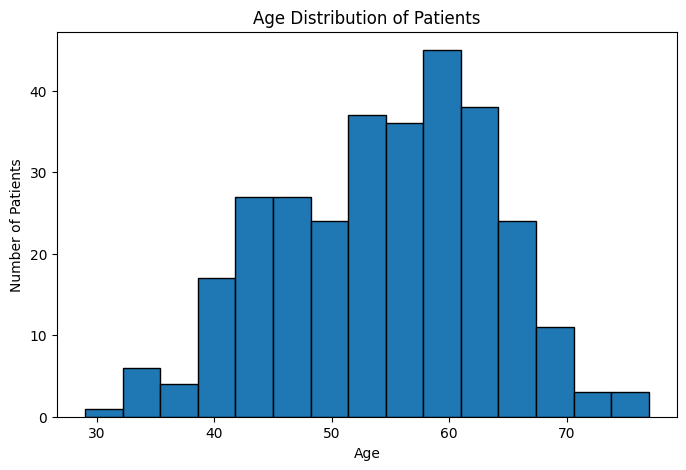

In [7]:
# Age distribution
plt.figure(figsize=(8, 5))

plt.hist(
    heart_df["age"],
    bins=15,
    edgecolor="black"
)

plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Age Distribution of Patients")
plt.show()

Cell 8 — Correlation matrix

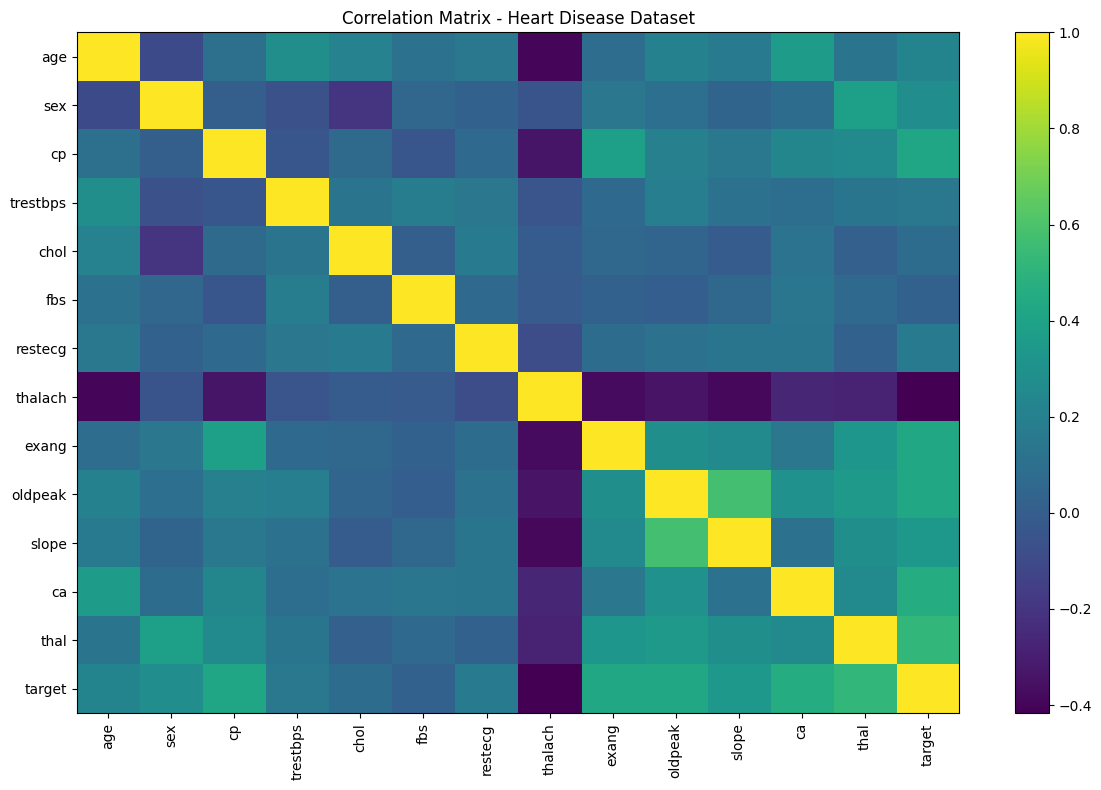

In [8]:
plt.figure(figsize=(12, 8))

correlation = heart_df.corr()

plt.imshow(correlation, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix - Heart Disease Dataset")
plt.tight_layout()
plt.show()

#Part B — LOGISTIC REGRESSION

The PDF explicitly proposes a baseline Logistic Regression classifier and evaluation using accuracy, ROC-AUC and confusion matrix.

Cell 9 — Prepare training and testing data

In [9]:
# Separate features and target
X = heart_df.drop("target", axis=1)
y = heart_df["target"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


Cell 10 — Train Logistic Regression

In [10]:
# Create Logistic Regression model
model = LogisticRegression(
    max_iter=2000
)

# Train model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


Cell 11 — Make predictions

In [11]:
# Predictions
y_pred = model.predict(X_test)

# Probability predictions for ROC-AUC
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


Cell 12 — Evaluate model

In [12]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Model Evaluation")
print("----------------------------")
print("Accuracy :", round(accuracy, 4))
print("ROC-AUC  :", round(roc_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Evaluation
----------------------------
Accuracy : 0.8689
ROC-AUC  : 0.9524

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



Cell 13 — Confusion Matrix

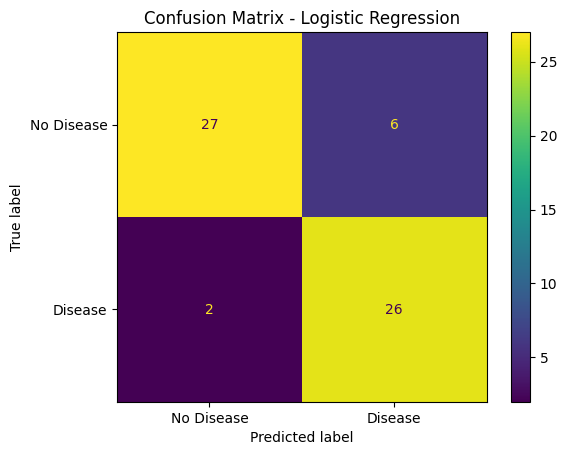

In [13]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

#Part C — ECG SIGNAL DATA

The PDF specifies the MIT-BIH Arrhythmia Database from PhysioNet and specifically suggests loading record 100 using wfdb.

Cell 14 — Load MIT-BIH ECG record 100

In [14]:
# Load ECG record 100 from MIT-BIH Arrhythmia Database

record = wfdb.rdrecord(
    "100",
    pn_dir="mitdb"
)

annotation = wfdb.rdann(
    "100",
    "atr",
    pn_dir="mitdb"
)

print("ECG record loaded successfully.")

print("Sampling frequency:", record.fs)
print("Number of samples:", record.sig_len)
print("Number of channels:", record.n_sig)
print("Channel names:", record.sig_name)

ECG record loaded successfully.
Sampling frequency: 360
Number of samples: 650000
Number of channels: 2
Channel names: ['MLII', 'V5']


Cell 15 — Display ECG signal information

In [15]:
# Extract first ECG channel
ecg_signal = record.p_signal[:, 0]

print("ECG signal length:", len(ecg_signal))
print("Sampling frequency:", record.fs, "Hz")

print("\nFirst 10 ECG samples:")
print(ecg_signal[:10])

print("\nNumber of annotations:", len(annotation.sample))

ECG signal length: 650000
Sampling frequency: 360 Hz

First 10 ECG samples:
[-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]

Number of annotations: 2274


Cell 16 — Plot ECG waveform

The lab requires plotting a segment of the ECG waveform and showing beat annotations.

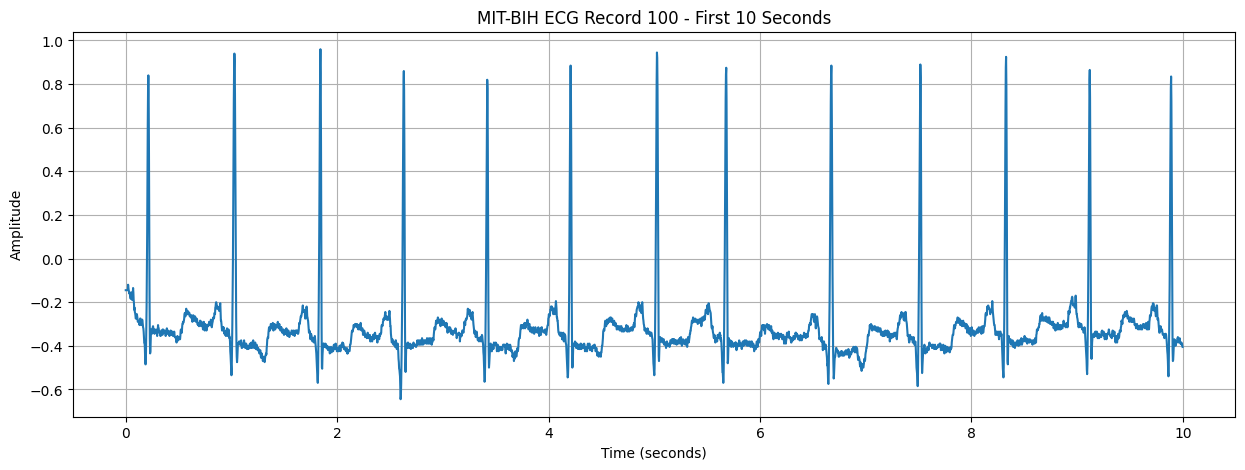

In [16]:
# Plot first 10 seconds of ECG

fs = record.fs

start_sample = 0
end_sample = int(10 * fs)

time = np.arange(start_sample, end_sample) / fs

plt.figure(figsize=(15, 5))

plt.plot(
    time,
    ecg_signal[start_sample:end_sample]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("MIT-BIH ECG Record 100 - First 10 Seconds")

plt.grid(True)
plt.show()

Cell 17 — ECG with beat annotations

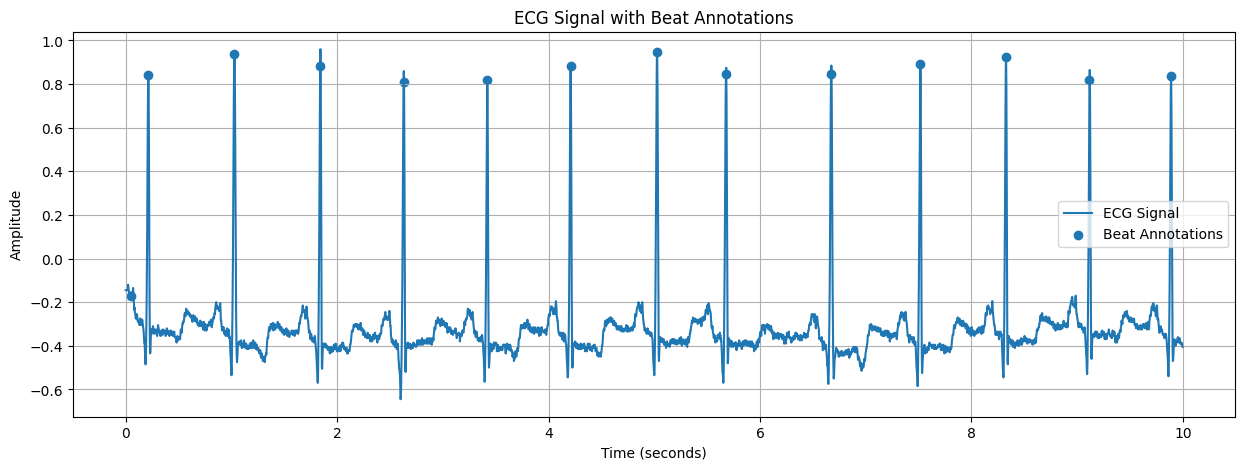

Annotations in first 10 seconds:
Time: 0.050 sec, Annotation: +
Time: 0.214 sec, Annotation: N
Time: 1.028 sec, Annotation: N
Time: 1.839 sec, Annotation: N
Time: 2.628 sec, Annotation: N
Time: 3.419 sec, Annotation: N
Time: 4.208 sec, Annotation: N
Time: 5.025 sec, Annotation: N
Time: 5.678 sec, Annotation: A
Time: 6.672 sec, Annotation: N
Time: 7.517 sec, Annotation: N
Time: 8.328 sec, Annotation: N
Time: 9.117 sec, Annotation: N
Time: 9.889 sec, Annotation: N


In [17]:
# Plot ECG with annotations

start_sample = 0
end_sample = int(10 * fs)

plt.figure(figsize=(15, 5))

plt.plot(
    time,
    ecg_signal[start_sample:end_sample],
    label="ECG Signal"
)

# Select annotations within first 10 seconds
annotation_samples = annotation.sample

mask = (
    (annotation_samples >= start_sample) &
    (annotation_samples < end_sample)
)

ann_samples = annotation_samples[mask]
ann_symbols = np.array(annotation.symbol)[mask]

# Convert annotation samples to time
ann_times = ann_samples / fs

# Get ECG values at annotation points
ann_values = ecg_signal[ann_samples]

plt.scatter(
    ann_times,
    ann_values,
    marker="o",
    label="Beat Annotations"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("ECG Signal with Beat Annotations")

plt.legend()
plt.grid(True)
plt.show()

print("Annotations in first 10 seconds:")
for t, symbol in zip(ann_times, ann_symbols):
    print(f"Time: {t:.3f} sec, Annotation: {symbol}")

#Part D — ECG BEAT INTERVAL / HEART-RATE STATISTICS

The PDF asks for basic heart-rate variability or beat interval statistics.

Cell 18 — Calculate beat intervals

In [18]:
# Extract beat annotation locations
beat_samples = annotation.sample

# Convert samples to seconds
beat_times = beat_samples / fs

# Calculate intervals between consecutive beats
beat_intervals = np.diff(beat_times)

print("Number of detected intervals:", len(beat_intervals))

print("\nFirst 10 beat intervals:")
print(beat_intervals[:10])

print("\nMean Beat Interval:",
      round(np.mean(beat_intervals), 4),
      "seconds")

print("Standard Deviation:",
      round(np.std(beat_intervals), 4),
      "seconds")

print("Minimum Beat Interval:",
      round(np.min(beat_intervals), 4),
      "seconds")

print("Maximum Beat Interval:",
      round(np.max(beat_intervals), 4),
      "seconds")

Number of detected intervals: 2273

First 10 beat intervals:
[0.16388889 0.81388889 0.81111111 0.78888889 0.79166667 0.78888889
 0.81666667 0.65277778 0.99444444 0.84444444]

Mean Beat Interval: 0.7943 seconds
Standard Deviation: 0.0506 seconds
Minimum Beat Interval: 0.1639 seconds
Maximum Beat Interval: 1.1306 seconds


Cell 19 — Estimate heart rate

In [19]:
# Estimate heart rate from mean beat interval

mean_interval = np.mean(beat_intervals)

heart_rate = 60 / mean_interval

print("Estimated Average Heart Rate:",
      round(heart_rate, 2),
      "beats per minute")

Estimated Average Heart Rate: 75.54 beats per minute


#Part E — TEXTUAL DATA

The PDF requires a synthetic/small clinical note, followed by tokenization, word-frequency calculation and key-term extraction.

Cell 20 — Clinical text

In [20]:
clinical_note = """
Patient is a 55 year old male.
The patient reports chest pain during physical activity.
He also reports shortness of breath and occasional fatigue.
Blood pressure is elevated.
The patient has a history of high cholesterol.
Further cardiovascular evaluation is recommended.
"""

print("Clinical Note:")
print(clinical_note)

Clinical Note:

Patient is a 55 year old male.
The patient reports chest pain during physical activity.
He also reports shortness of breath and occasional fatigue.
Blood pressure is elevated.
The patient has a history of high cholesterol.
Further cardiovascular evaluation is recommended.



Cell 21 — Clean and tokenize text

In [31]:
import re

# Convert text to lowercase
text = clinical_note.lower()

# Extract words
words = re.findall(r'\b[a-z]+\b', text)

print("Tokens:")
print(words)

print("\nTotal number of words:", len(words))

Tokens:
['patient', 'is', 'a', 'year', 'old', 'male', 'the', 'patient', 'reports', 'chest', 'pain', 'during', 'physical', 'activity', 'he', 'also', 'reports', 'shortness', 'of', 'breath', 'and', 'occasional', 'fatigue', 'blood', 'pressure', 'is', 'elevated', 'the', 'patient', 'has', 'a', 'history', 'of', 'high', 'cholesterol', 'further', 'cardiovascular', 'evaluation', 'is', 'recommended']

Total number of words: 40


Cell 22 — Word frequency

In [22]:
# Calculate word frequency
word_frequency = Counter(words)

print("Word Frequency:")
for word, count in word_frequency.most_common():
    print(word, ":", count)

Word Frequency:
patient : 3
is : 3
a : 2
the : 2
reports : 2
of : 2
year : 1
old : 1
male : 1
chest : 1
pain : 1
during : 1
physical : 1
activity : 1
he : 1
also : 1
shortness : 1
breath : 1
and : 1
occasional : 1
fatigue : 1
blood : 1
pressure : 1
elevated : 1
has : 1
history : 1
high : 1
cholesterol : 1
further : 1
cardiovascular : 1
evaluation : 1
recommended : 1


Cell 23 — Extract key medical terms

In [23]:
medical_terms = [
    "chest",
    "pain",
    "shortness",
    "breath",
    "fatigue",
    "blood",
    "pressure",
    "cholesterol",
    "cardiovascular",
    "evaluation"
]

found_terms = []

for word in medical_terms:
    if word in words:
        found_terms.append(word)

print("Key Medical Terms Found:")
print(found_terms)

Key Medical Terms Found:
['chest', 'pain', 'shortness', 'breath', 'fatigue', 'blood', 'pressure', 'cholesterol', 'cardiovascular', 'evaluation']


#Part F — IMAGE DATA

The PDF describes image ingestion using Pillow/OpenCV, including reading, normalization, resizing and metadata extraction.

For the lab demonstration, we can create a simple synthetic medical-style image so that the notebook does not depend on a random external image URL.

Cell 24 — Create a synthetic medical image

In [24]:
# Create a synthetic grayscale medical-style image

image_array = np.random.randint(
    0,
    256,
    size=(256, 256),
    dtype=np.uint8
)

image = Image.fromarray(image_array)

print("Image loaded successfully.")
print("Image size:", image.size)
print("Image mode:", image.mode)

Image loaded successfully.
Image size: (256, 256)
Image mode: L


Cell 25 — Display image

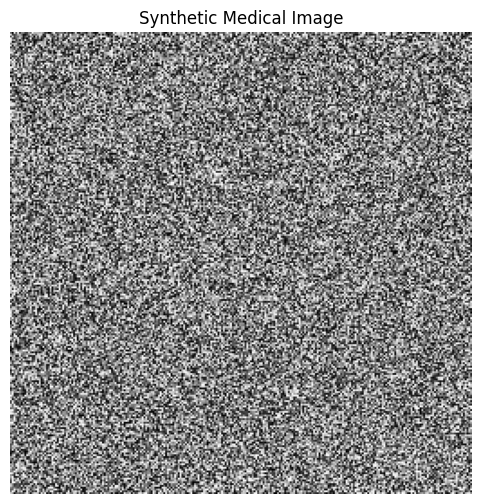

In [25]:
plt.figure(figsize=(6, 6))

plt.imshow(image, cmap="gray")

plt.title("Synthetic Medical Image")
plt.axis("off")

plt.show()

Cell 26 — Resize and normalize image

In [26]:
# Resize image
resized_image = image.resize((128, 128))

# Convert image to NumPy array
image_data = np.array(resized_image)

# Normalize pixel values between 0 and 1
normalized_image = image_data / 255.0

print("Original image size:", image.size)
print("Resized image size:", resized_image.size)

print("Minimum normalized pixel value:",
      normalized_image.min())

print("Maximum normalized pixel value:",
      normalized_image.max())

Original image size: (256, 256)
Resized image size: (128, 128)
Minimum normalized pixel value: 0.09019607843137255
Maximum normalized pixel value: 0.9098039215686274


Cell 27 — Display normalized image

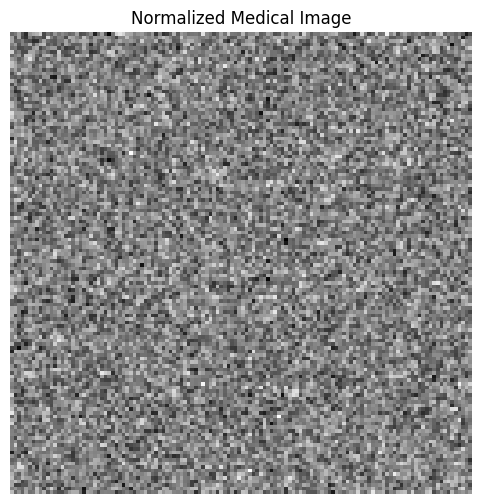

In [27]:
plt.figure(figsize=(6, 6))

plt.imshow(
    normalized_image,
    cmap="gray"
)

plt.title("Normalized Medical Image")
plt.axis("off")

plt.show()

#Part G — UNIFIED DATASET / MULTIMODAL PIPELINE

The experiment's design calls for separate loaders, an inspector/validator, preprocessing and an optional fusion interface.

Cell 28 — Create modular loader functions

In [28]:
def load_tabular_data(url):
    columns = [
        "age", "sex", "cp", "trestbps", "chol",
        "fbs", "restecg", "thalach", "exang",
        "oldpeak", "slope", "ca", "thal", "target"
    ]

    df = pd.read_csv(
        url,
        names=columns,
        na_values="?"
    )

    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.fillna(df.median(numeric_only=True))

    return df


def load_ecg_data(record_name="100"):
    record = wfdb.rdrecord(
        record_name,
        pn_dir="mitdb"
    )

    annotation = wfdb.rdann(
        record_name,
        "atr",
        pn_dir="mitdb"
    )

    return record, annotation


def load_text_data(text):
    return text


def load_image_data(image):
    return np.array(image)

Cell 29 — Use the loaders

In [29]:
# Tabular loader
tabular_data = load_tabular_data(url)

# ECG loader
ecg_record, ecg_annotation = load_ecg_data("100")

# Text loader
text_data = load_text_data(clinical_note)

# Image loader
image_data = load_image_data(resized_image)

print("Multimodal data loaded successfully.")

print("\nTABULAR DATA")
print(tabular_data.shape)

print("\nECG DATA")
print(ecg_record.p_signal.shape)

print("\nTEXT DATA")
print(len(text_data), "characters")

print("\nIMAGE DATA")
print(image_data.shape)

Multimodal data loaded successfully.

TABULAR DATA
(303, 14)

ECG DATA
(650000, 2)

TEXT DATA
274 characters

IMAGE DATA
(128, 128)


#Part H — FINAL INSPECTION
Cell 30 — Dataset summary

In [30]:
print("=" * 60)
print("MULTIMODAL HEALTHCARE DATA SUMMARY")
print("=" * 60)

print("\n1. TABULAR / MEDICAL DATA")
print("Records:", tabular_data.shape[0])
print("Features:", tabular_data.shape[1])
print("Missing values:", tabular_data.isnull().sum().sum())

print("\n2. ECG SIGNAL DATA")
print("Record:", "100")
print("Sampling frequency:", ecg_record.fs, "Hz")
print("Samples:", ecg_record.sig_len)
print("Channels:", ecg_record.n_sig)

print("\n3. TEXT DATA")
print("Characters:", len(text_data))
print("Words:", len(re.findall(r'\b[a-zA-Z]+\b', text_data)))

print("\n4. IMAGE DATA")
print("Height:", image_data.shape[0])
print("Width:", image_data.shape[1])

print("\n" + "=" * 60)
print("LAB EXPERIMENT 1 COMPLETED SUCCESSFULLY")
print("=" * 60)

MULTIMODAL HEALTHCARE DATA SUMMARY

1. TABULAR / MEDICAL DATA
Records: 303
Features: 14
Missing values: 0

2. ECG SIGNAL DATA
Record: 100
Sampling frequency: 360 Hz
Samples: 650000
Channels: 2

3. TEXT DATA
Characters: 274
Words: 40

4. IMAGE DATA
Height: 128
Width: 128

LAB EXPERIMENT 1 COMPLETED SUCCESSFULLY
